In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.10.1 anndata==0.10.7 umap==0.5.6 numpy==1.26.4 scipy==1.13.0 pandas==2.2.2 scikit-learn==1.4.2 statsmodels==0.14.2 pynndescent==0.5.12


In [3]:
results_file = './tabula-muris-senis-bbknn-processed-official-annotations.h5ad'

In [4]:
adata = sc.read(results_file)

/home/kojima/anaconda3/envs/singlecell/lib/python3.10/site-packages/anndata/compat/__init__.py:311: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/kojima/anaconda3/envs/singlecell/lib/python3.10/site-packages/anndata/compat/__init__.py:311: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


In [5]:
adata

AnnData object with n_obs × n_vars = 356213 × 20116
    obs: 'age', 'batch', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'n_counts', 'n_genes', 'sex', 'subtissue', 'tissue', 'tissue_free_annotation', 'louvain', 'leiden', 'tissue_FACS_droplet'
    var: 'n_cells-0', 'n_cells-1', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'age_colors', 'leiden', 'louvain', 'louvain_colors', 'method_colors', 'neighbors', 'pca', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [6]:
adata.obs

,age,batch,cell,cell_ontology_class,cell_ontology_id,free_annotation,method,mouse.id,n_counts,n_genes,sex,subtissue,tissue,tissue_free_annotation,louvain,leiden,tissue_FACS_droplet
index,,,,,,,,,,,,,,,,,
AAACCTGCAGGGTACA-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACCTGCAGGGTACA,keratinocyte,NA,filiform,droplet,24-M-60,5482.0,2107.0,male,nan,Tongue,Tongue,5,3,Tongue
AAACCTGCAGTAAGCG-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACCTGCAGTAAGCG,keratinocyte,NA,suprabasal,droplet,24-M-60,21855.0,3481.0,male,nan,Tongue,Tongue,27,31,Tongue
AAACCTGTCATTATCC-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACCTGTCATTATCC,keratinocyte,NA,suprabasal,droplet,24-M-60,10942.0,2599.0,male,nan,Tongue,Tongue,27,31,Tongue
AAACGGGGTACAGTGG-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACGGGGTACAGTGG,keratinocyte,NA,suprabasal differentiating,droplet,24-M-60,20665.0,3468.0,male,nan,Tongue,Tongue,24,11,Tongue
AAACGGGGTCTTCTCG-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACGGGGTCTTCTCG,keratinocyte,NA,suprabasal differentiating,droplet,24-M-60,12925.0,3189.0,male,nan,Tongue,Tongue,5,3,Tongue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P8_MAA001690_S20.mus-2-1-1,21m,1,nan,basal cell,NA,basal cell,facs,21_54_F,146918.0,3523.0,female,Mammary_Gland,Mammary_Gland,nan,34,42,Mammary_Gland
P8_MAA001700_S104.mus-2-1-1,21m,1,nan,basal cell,NA,basal cell,facs,21_55_F,1027448.0,4476.0,female,Mammary_Gland,Mammary_Gland,nan,34,42,Mammary_Gland
P9_B000485_S69.mus-2-1-1,18m,1,nan,basal cell,NA,basal cell,facs,18_47_F,1184028.0,2980.0,female,Mammary_Gland,Mammary_Gland,nan,34,42,Mammary_Gland


In [7]:
adata.var

,n_cells-0,n_cells-1,means,dispersions,dispersions_norm,highly_variable
index,,,,,,
Xkr4,147,1033,0.002346,1.637490,-0.151752,False
Rp1,233,512,0.001932,3.440012,1.884511,False
Sox17,27289,8682,0.364107,2.981940,1.346346,True
Mrpl15,95312,36628,0.421241,3.758855,2.255921,True
Lypla1,86096,33500,0.375493,1.401394,-0.504083,False
...,...,...,...,...,...,...
LOC434960,5,8,0.000023,1.026086,-0.842439,False
LOC380994,32,85,0.000307,2.609386,0.946174,False
LOC100041346,19,47,0.000091,0.838271,-1.054610,False


In [8]:
adata.var[adata.var["highly_variable"]==True]

,n_cells-0,n_cells-1,means,dispersions,dispersions_norm,highly_variable
index,,,,,,
Sox17,27289,8682,0.364107,2.981940,1.346346,True
Mrpl15,95312,36628,0.421241,3.758855,2.255921,True
Msc,3400,3664,0.052632,2.425148,0.738045,True
Rdh10,21004,11328,0.126575,2.402273,0.712204,True
Stau2,7725,9509,0.039526,3.206601,1.620833,True
...,...,...,...,...,...,...
S100g,12536,2922,0.705977,6.661724,4.356267,True
Tmem27,19194,5088,0.699537,3.820078,1.635117,True
Gpm6b,23794,24735,0.523495,4.070674,2.620984,True


In [9]:
adata_D=adata[:,adata.var["highly_variable"]==True]

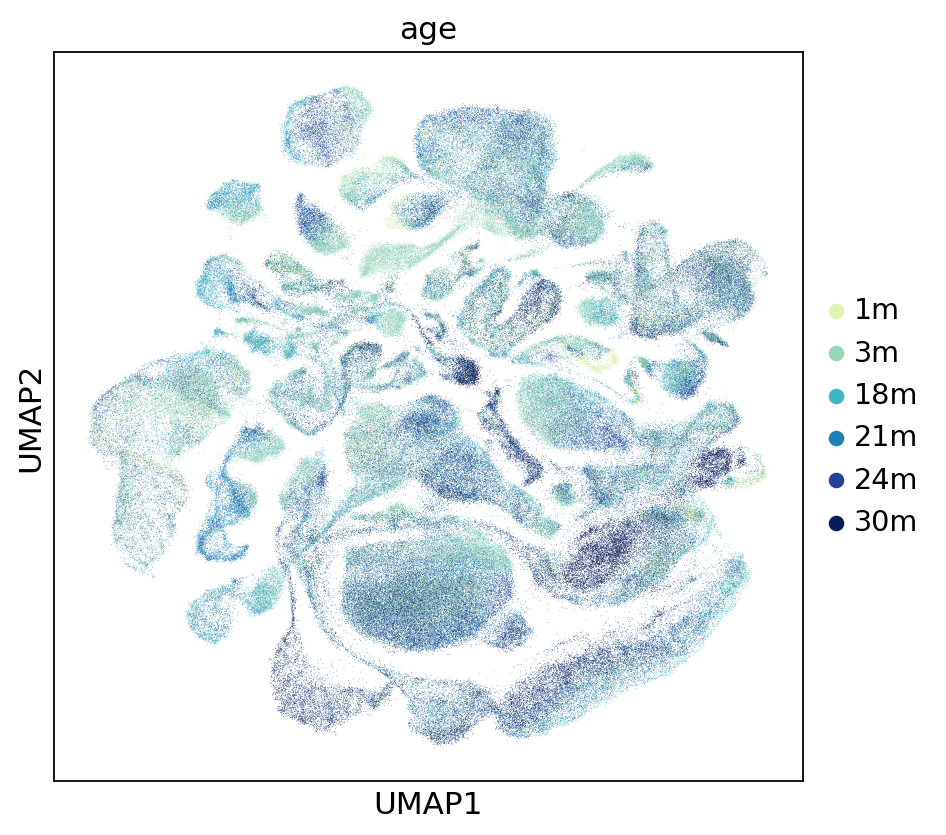

In [10]:
# Inital setting for plot size
from matplotlib import rcParams

FIGSIZE = (6, 6)
rcParams["figure.figsize"] = FIGSIZE

sc.pl.umap(adata_D, color="age")
#sc.pl.umap(adata_D, color=["batch", "louvain"])

/home/kojima/anaconda3/envs/singlecell/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


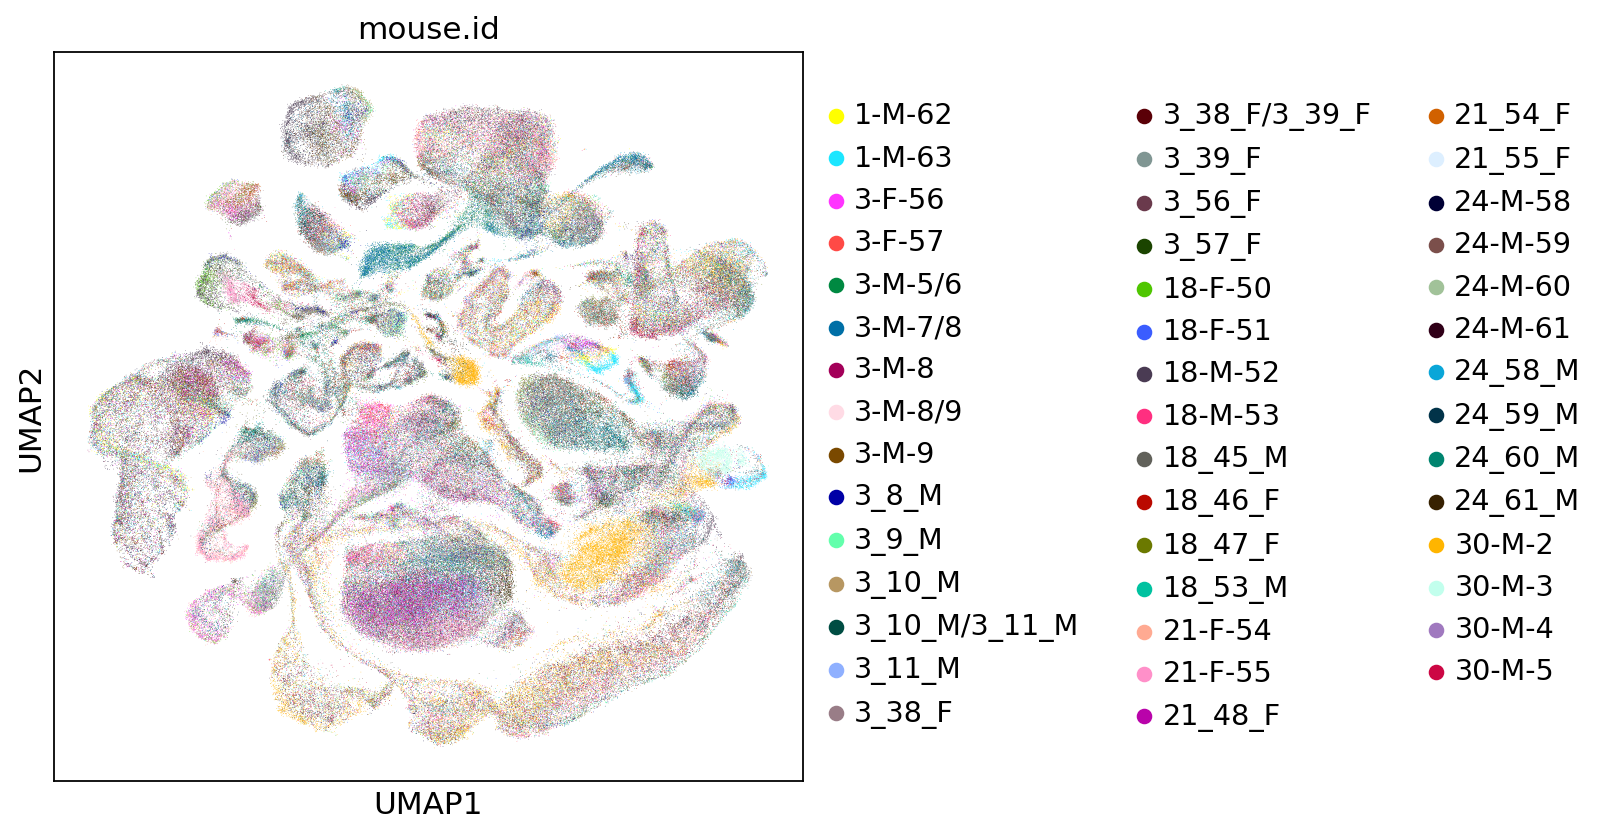

In [11]:
sc.pl.umap(adata_D, color="mouse.id")

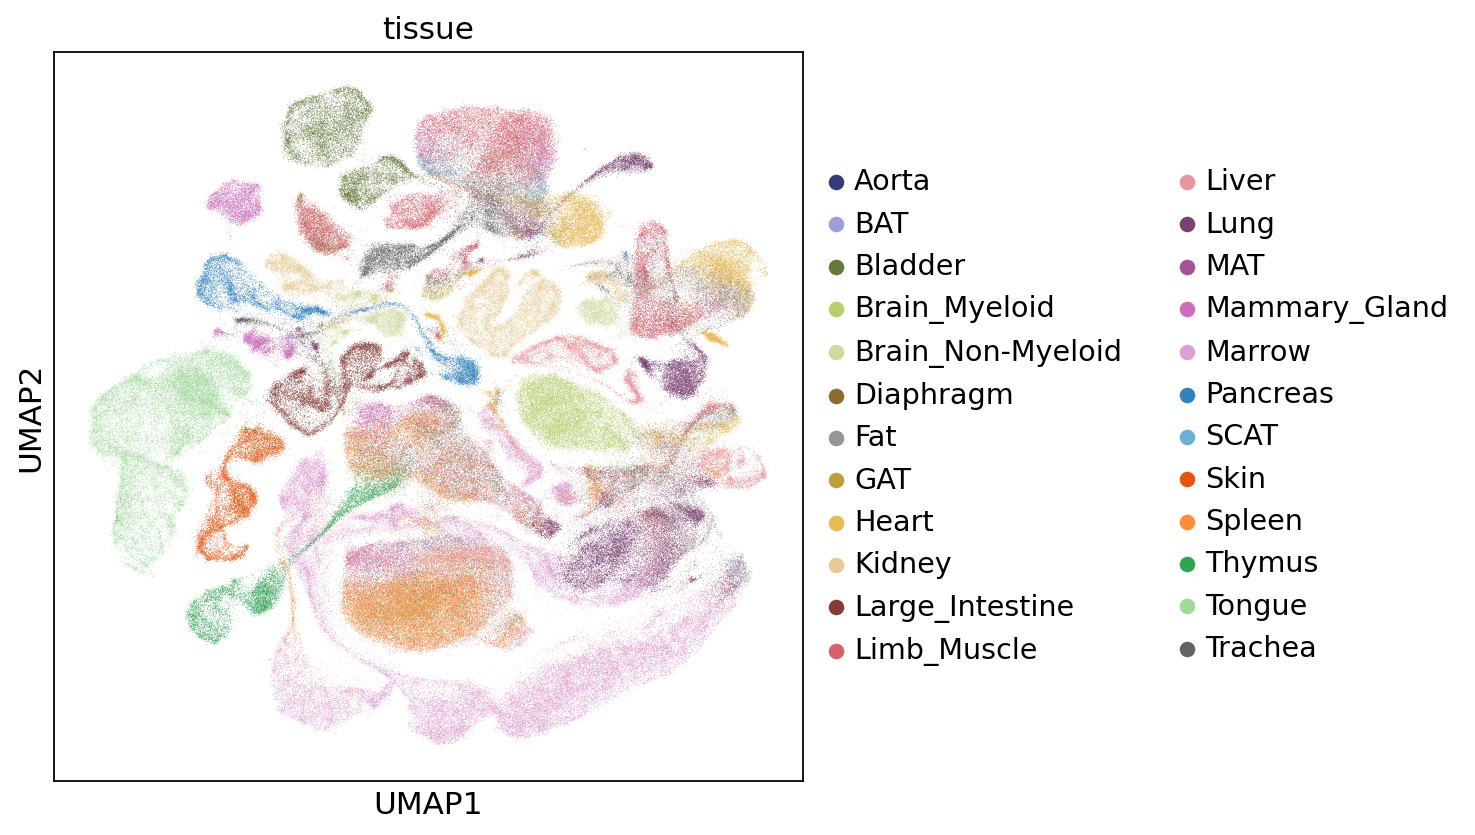

In [12]:
sc.pl.umap(adata_D, color="tissue")

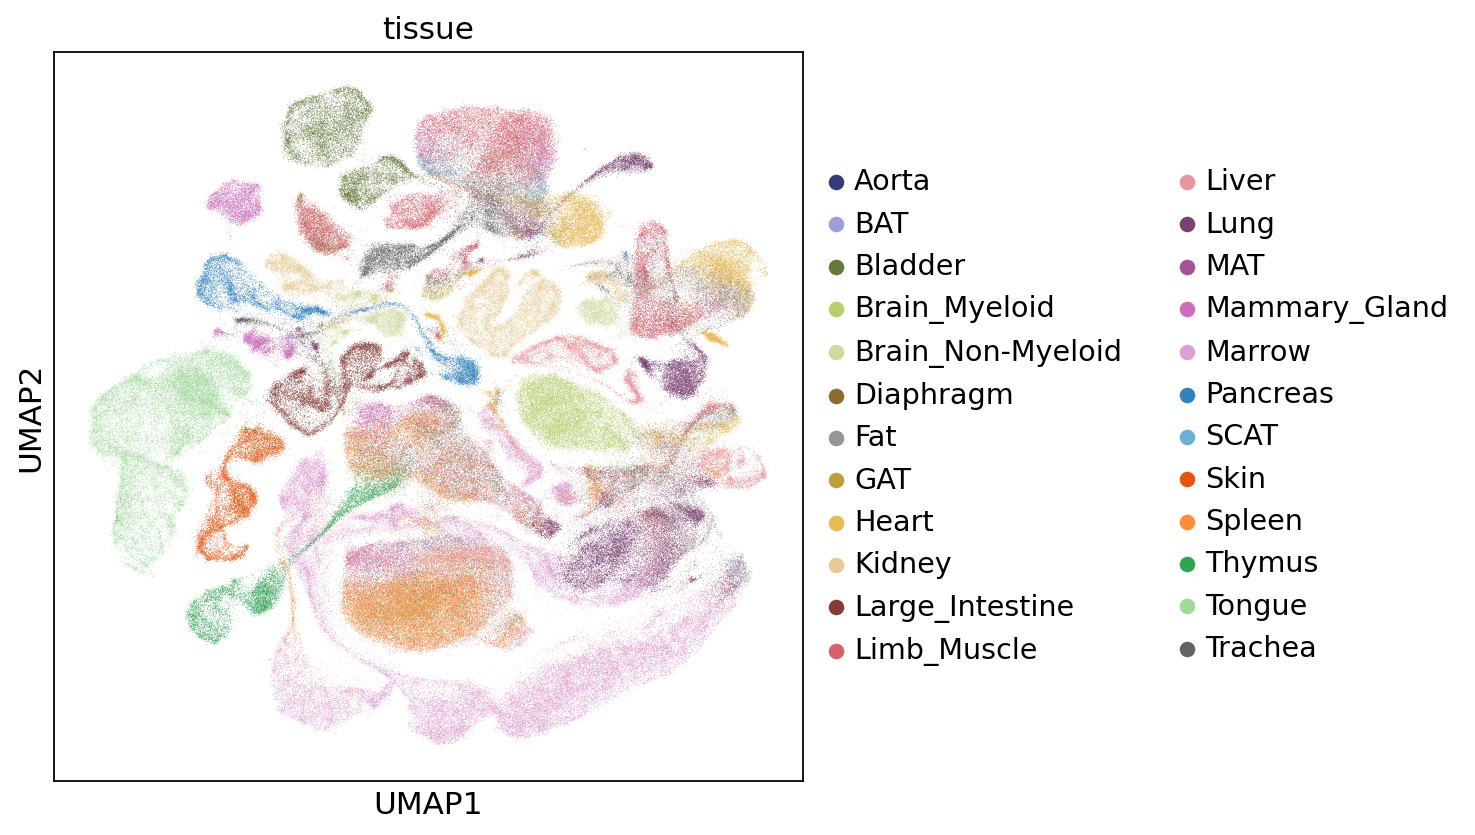

In [13]:
sc.pl.umap(adata_D, color="tissue")

In [14]:
print(len(adata.obs["tissue"].unique().tolist()))
#for el in adata.obs["tissue"].unique().tolist():
#    adata[obs["tissue"]==el, adata.var["highly_variable"]==True ]

24


In [20]:
var=adata.var[adata.var["highly_variable"]==True].index.tolist()
sorted(var)

['0610010O12Rik',
 '0610040J01Rik',
 '1100001G20Rik',
 '1110002N22Rik',
 '1110032A04Rik',
 '1110050K14Rik',
 '1190002H23Rik',
 '1500010J02Rik',
 '1500015O10Rik',
 '1600029D21Rik',
 '1700019D03Rik',
 '1700030C10Rik',
 '1700084E18Rik',
 '1700086L19Rik',
 '1810011O10Rik',
 '1810012P15Rik',
 '1810030J14Rik',
 '1810046K07Rik',
 '1810065E05Rik',
 '2010001M09Rik',
 '2010016I18Rik',
 '2010109I03Rik',
 '2200002D01Rik',
 '2210010C04Rik',
 '2210404O07Rik',
 '2210408F21Rik',
 '2210415F13Rik',
 '2310002J15Rik',
 '2310002L13Rik',
 '2310008H04Rik',
 '2310034C09Rik',
 '2310042D19Rik',
 '2310046O06Rik',
 '2310050C09Rik',
 '2310061N02Rik',
 '2310068J16Rik',
 '2310079G19Rik',
 '2410091C18Rik',
 '2510012J08Rik',
 '2610019F03Rik',
 '2610528A11Rik',
 '2700089E24Rik',
 '2810007J24Rik',
 '2810405K02Rik',
 '2810417H13Rik',
 '2810468N07Rik',
 '2900041M22Rik',
 '3110079O15Rik',
 '4632415L05Rik',
 '4921513D23Rik',
 '4930549G23Rik',
 '4933434E20Rik',
 '5031439G07Rik',
 '5430417L22Rik',
 '5430421N21Rik',
 '5730409E

In [19]:
if "APP" in var:
    print("APP")
if "PSEN1" in var:
    print("PSEN1")
if "PSEN2" in var:
    print("PSEN2")
